In [14]:
%pip install numpy==1.19.5
!pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.8/24.8 MB 28.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 25.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.20.1
    Uninstalling scikit-learn-0.20.1:
      Successfully uninstalled scikit-learn-0.20.1


In [21]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X, y = make_classification(n_samples=1000, n_features=10, n_informative=4, random_state=42)
df = pd.DataFrame(X)

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [23]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

In [24]:
agglo = AgglomerativeClustering(n_clusters=4)
df['Agglo_Cluster'] = agglo.fit_predict(X_scaled)

In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA_1'] = X_pca[:, 0]
df['PCA_2'] = X_pca[:, 1]

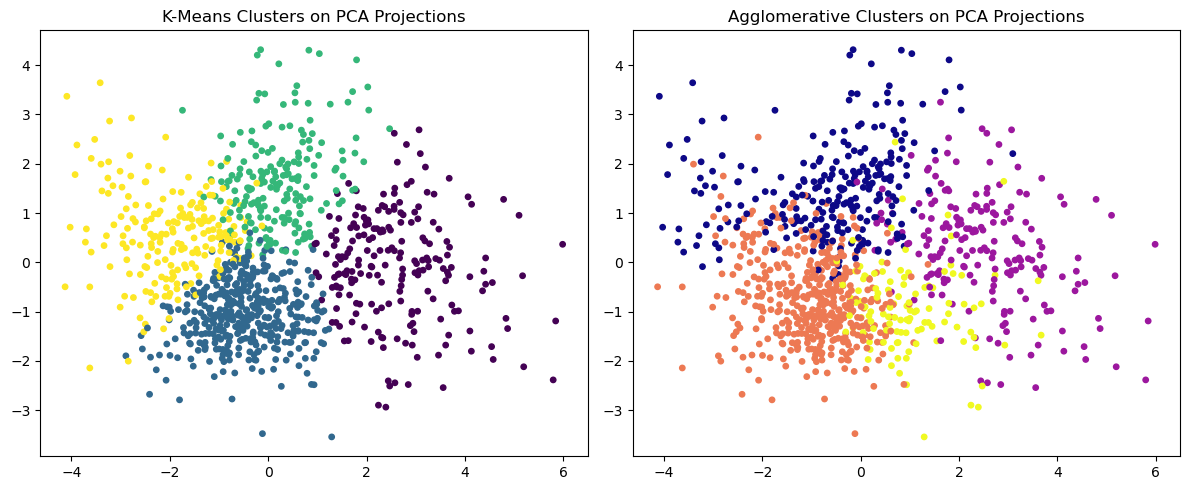

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(df['PCA_1'], df['PCA_2'], c=df['KMeans_Cluster'], cmap='viridis', s=15)
ax1.set_title('K-Means Clusters on PCA Projections')

ax2.scatter(df['PCA_1'], df['PCA_2'], c=df['Agglo_Cluster'], cmap='plasma', s=15)
ax2.set_title('Agglomerative Clusters on PCA Projections')

plt.tight_layout()
plt.show()